# Optimal $R^2$ threshold in Gaussian fitting to peaks

In [52]:
%cd ..
from helpers.helpersGeneration import *
from helpers.helpersTracking import *
from helpers.helpersStatistics import *
from helpers.helpersAssignment import *

c:\Users\armel


In [53]:
# simulation params 
nparticles=23
nframes=1
nposframe=5
D_list = [
    (0.10, 0.30),  
    (0.50, 0.10),  
    (1.50, 0.15),  
    (3.50, 0.10),
    (4.00, 0.15),
    (5.00, 0.20)
]

In [54]:
trajectories = simulate_brownian_motion(
    nparticles=nparticles,
    nframes=nframes,
    nposframe=nposframe,
    D_list=D_list,
    dt=1.0,
    anisotropy_ratio_range=(1.0, 1.0),
    theta_range=(np.deg2rad(0), np.deg2rad(0)),
    frame_size=(128, 128),
    intensity_mean=700,
    intensity_std=300
)

image_props = {
    "particle_intensity": [700, 300],
    "background_intensity": [100, 30],
    "poisson_noise": 100,
    "output_size": 128,
    "upsampling_factor": 5,
    "resolution": 100e-9,
    "trajectory_unit": -1,
    "invert_y": True,
}

In [55]:
video= trajectories_to_global_video(
    trajectories, # still at subframe resolution
    nframes=nframes,
    nPosPerFrame=nposframe,
    image_props=image_props
)

In [56]:
trajectories_GT = create_GT_trajectories(trajectories, nposframe)

In [57]:
frames = video.astype(np.float32)
print(frames.shape)

(1, 128, 128)


In [58]:
# tuned version for the experiment

def localize_peaks_with_gaussian_fitting(frames, detected_peaks, r_squared_threshold=0.5, verbose=False, visualization=False, visualization_peak_idx=0):
    """ Fits a 5x5 square around detected peaks, use center pixel as initial guess, extract the center coordinates (floats) by gaussian fitting
    Args:
        frames: list of 2D numpy arrays representing the image frames
        detected_peaks: list of lists of detected peaks (as returned by detect_peaks), where each inner list corresponds to a frame and contains tuples of (x, y) coordinates of detected peaks in that frame.
        r_squared_threshold: minimum R-squared value for a fit to be considered valid.
    Returns:
        localized_peaks: list of lists of localized peaks (as returned by detect_peaks), where each inner list corresponds to a frame and contains tuples of (x, y) coordinates of localized peaks in that frame.
    """
    total_kept_fits = 0
    localized_peaks = []

    for frame_idx, (frame, peaks) in enumerate(zip(frames, detected_peaks)):
        localized_frame_peaks = []
        for peak_idx, peak in enumerate(peaks):

            fitted = fit_gaussian_to_peak(frame, peak, verbose=verbose)
            pos_fit = (fitted[0], fitted[1]) if fitted is not None else None
            A_fit = fitted[2] if fitted is not None else None
            sigma_fit = fitted[3] if fitted is not None else None
            amp_fit = A_fit / (2 * np.pi * sigma_fit**2) if A_fit is not None and sigma_fit is not None else None
            r_squared = fitted[5] if fitted is not None else None
            localized_peak = (pos_fit, amp_fit, sigma_fit, r_squared) if pos_fit is not None and amp_fit is not None and sigma_fit is not None else None

            if localized_peak is not None and r_squared is not None and r_squared >= r_squared_threshold:
                localized_frame_peaks.append(localized_peak)
                total_kept_fits += 1
                print('added a peak')                
                if verbose:
                    print(
                        f"[Frame {frame_idx}] Fitted center for peak at ({peak[0]}, {peak[1]}): "
                        f"({pos_fit[0]:.2f}, {pos_fit[1]:.2f}), amplitude {amp_fit:.2f}, sigma {sigma_fit:.2f}, R-squared {r_squared:.3f}"
                    )
            elif r_squared is None:
                if verbose:
                    print('[Frame {}] No computed R-squared for peak at ({}, {}) in frame {}.'.format(frame_idx, peak[0], peak[1], frame_idx))
            elif r_squared < r_squared_threshold:
                print('peak rejected')
                if verbose:
                    print('[Frame {}] Poor fit for peak at ({}, {}) in frame {}: R-squared = {:.3f} (below threshold of {}).'.format(frame_idx, peak[0], peak[1], frame_idx, r_squared, r_squared_threshold))

            # # visualize only the first peak of the first frame
            # if visualization and frame_idx == 0 and peak_idx == visualization_peak_idx and fitted is not None:
            #     visualize_gaussian_fit(frame, peak, fitted)

        localized_peaks.append(localized_frame_peaks)

    return localized_peaks, total_kept_fits

In [59]:
# tuned version for the experiment
def track(
    frames,
    trajectories_GT,
    max_distance=10,
    min_length=5, # à affiner, trouver un bon min, taille min Emilien
    r_squared_threshold=0.5,
    algo_peak2peak='hungarian',
    algo_traj2traj='hungarian',
    cost_function=None,
    verbose_loc=False,
    visualization_loc=False,
    verbose_assignment=False
):
    detected_peaks = detect_peaks(frames)
    
    localized_peaks = localize_peaks_with_gaussian_fitting(frames, 
                                                           detected_peaks, 
                                                           r_squared_threshold=r_squared_threshold, 
                                                           verbose=verbose_loc, 
                                                           visualization=visualization_loc, 
                                                           visualization_peak_idx=1)

    # trajectories_localization, cost_peak2peak = track_peaks_to_trajectories(
    #                                                     peaks=localized_peaks,
    #                                                     max_distance=max_distance,
    #                                                     min_length=min_length,
    #                                                     algorithm=algo_peak2peak,
    #                                                     cost_function=cost_function,
    #                                             )

    # trajectories_localization, cost_traj2traj, assignment_localization = assign_trajectories(trajectories_localization,
    #                                                                                          trajectories_GT, 
    #                                                                                          algorithm=algo_traj2traj, 
    #                                                                                          verbose=verbose_assignment)

    return localized_peaks

In [60]:
r_squared_range = np.linspace(0.4, 1.0, 13)
# ground truth number of fits is nparticles * nframes, since we have nparticles per frame and nframes total frames
tot_particles = nparticles * nframes
kept_fits_range = []

for r_squared in r_squared_range:
   print(f"R-squared threshold: {r_squared:.2f}")
   localized_peaks_exp, total_kept_fits = track(frames, trajectories_GT, r_squared_threshold=r_squared, verbose_loc=False)
   print(f"Number of localized peaks: {total_kept_fits}")
   kept_fits_range.append(total_kept_fits)

R-squared threshold: 0.40
added a peak
added a peak
added a peak
added a peak
added a peak
added a peak
added a peak
added a peak
added a peak
added a peak
added a peak
added a peak
added a peak
added a peak
added a peak
added a peak
added a peak
added a peak
added a peak
added a peak
added a peak
added a peak
added a peak
added a peak
added a peak
Number of localized peaks: 25
R-squared threshold: 0.45
added a peak
added a peak
added a peak
added a peak
added a peak
added a peak
added a peak
added a peak
added a peak
added a peak
added a peak
added a peak
added a peak
added a peak
added a peak
added a peak
added a peak
added a peak
added a peak
added a peak
added a peak
added a peak
added a peak
added a peak
added a peak
Number of localized peaks: 25
R-squared threshold: 0.50
added a peak
added a peak
added a peak
added a peak
added a peak
added a peak
added a peak
added a peak
added a peak
added a peak
added a peak
added a peak
added a peak
added a peak
added a peak
added a peak
adde

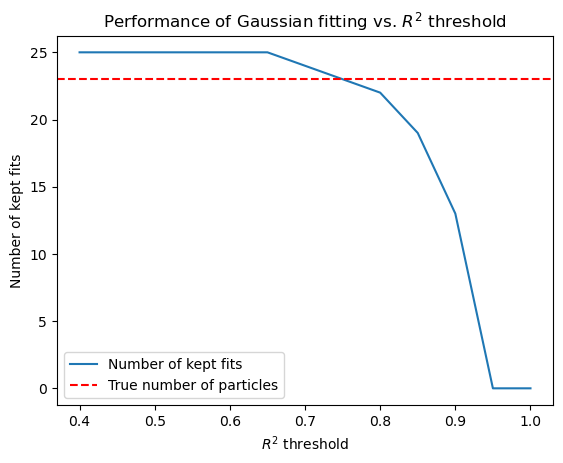

In [61]:
# plot the total number of kept fits as a function of the R-squared threshold
# also plot on top the true total number of particles (tot_particles)
import matplotlib.pyplot as plt
plt.plot(r_squared_range, kept_fits_range, label='Number of kept fits')
plt.axhline(y=tot_particles, color='r', linestyle='--', label='True number of particles')
plt.xlabel('$R^2$ threshold')
plt.ylabel('Number of kept fits')
plt.title('Performance of Gaussian fitting vs. $R^2$ threshold')
plt.legend()
plt.show()
